<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
Coefficients: 
 [25.98154972 38.59015875  0.19040528 61.27909654]
MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624


Text(0, 0.5, 'Predicted Y')

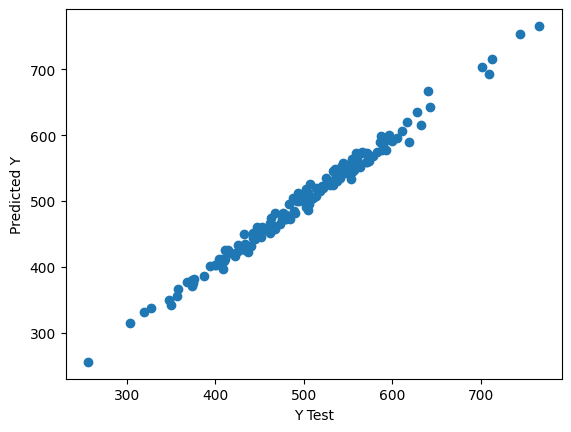

In [1]:
# Import necessary libraries (already done in the lab, but for completeness)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

# Load the Ecommerce Customers dataset
customers = pd.read_csv('Ecommerce Customers')

customers.head()    # View first 5 rows
customers.info()    # View column data types and non-null counts
customers.describe() # View statistical summary

# Define Features (Numerical columns only)
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

# Define Target
y = customers['Yearly Amount Spent']

# Split the data (using 30% for testing as seen in standard lab practices)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

lm = LinearRegression()
lm.fit(X_train, y_train)

# Print the coefficients
print('Coefficients: \n', lm.coef_)

predictions = lm.predict(X_test)

# Evaluation Metrics
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

# Visualize the predictions
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')